Processing work_dirs/RouteNet_N28_biased_loss_gn/roc_prc.csv...
Processing work_dirs/RouteNet_N28_biased_loss/roc_prc.csv...
Processing work_dirs/RouteNet_N28_baseline/roc_prc.csv...
Processing work_dirs/RouteNet_N28_baseline_gn/roc_prc.csv...


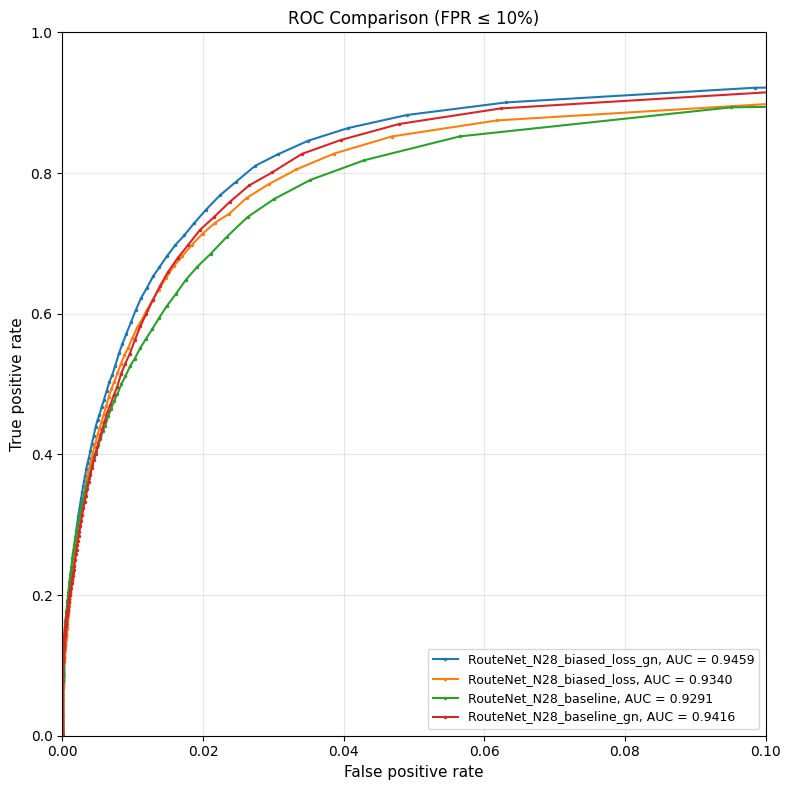

,tag,tp_0.10,fp_0.10,tn_0.10,fn_0.10,accuracy at 10% threshold,precision at 10% threshold,recall at 10% threshold,f1 at 10% threshold,tp,fp,tn,fn,accuracy,auc
0,RouteNet_N28_biased_loss_gn,1751600,713710,78620891,375047,0.986635,0.710499,0.823644,0.762899,129938965,137979206,6745271851,217265786,0.950868,0.945942
1,RouteNet_N28_biased_loss,1717880,727392,79916188,410508,0.986253,0.702531,0.807127,0.751206,128698959,138505287,8025117451,226768479,0.957123,0.934016
2,RouteNet_N28_baseline,1659251,582493,75933027,468429,0.986637,0.740161,0.779840,0.759483,121088491,129825847,7180848001,229330525,0.953119,0.929116
3,RouteNet_N28_baseline_gn,1724180,625382,76155815,399967,0.987005,0.733830,0.811705,0.770806,128114871,134177903,6221352501,218131621,0.947430,0.941618


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Define your CSV files here
csv_files = [
    "work_dirs/RouteNet_N28_biased_loss_gn/roc_prc.csv",
    "work_dirs/RouteNet_N28_biased_loss/roc_prc.csv",
    "work_dirs/RouteNet_N28_baseline/roc_prc.csv",
    "work_dirs/RouteNet_N28_baseline_gn/roc_prc.csv",
]

result = []
roc_curves = []  # Store ROC data for plotting

for csv_file in csv_files:
    print(f"Processing {csv_file}...")
    
    df = pd.read_csv(csv_file, header=None, names=["threshold", "id", "tn", "fp", "fn", "tp"])
    
    t = df
    no_negatives      = (t["fp"] == 0) & (t["tn"] == 0)
    no_positives      = (t["tp"] == 0) & (t["fn"] == 0)
    no_pred_positives = (t["tp"] == 0) & (t["fp"] == 0)
    df = t[~(no_negatives | no_positives | no_pred_positives)].copy() 
    
    df_filtered = df[df["threshold"] == 0.1].copy()
    
    m_result = {}
    m_result['tp_0.10'] = df_filtered['tp'].sum()
    m_result['fp_0.10'] = df_filtered['fp'].sum()
    m_result['tn_0.10'] = df_filtered['tn'].sum()
    m_result['fn_0.10'] = df_filtered['fn'].sum()
    m_result['accuracy at 10% threshold'] = (m_result['tp_0.10'] + m_result['tn_0.10']) / (m_result['tp_0.10'] + m_result['tn_0.10'] + m_result['fp_0.10'] + m_result['fn_0.10'])
    m_result['precision at 10% threshold'] = m_result['tp_0.10'] / (m_result['tp_0.10'] + m_result['fp_0.10'])
    m_result['recall at 10% threshold'] = m_result['tp_0.10'] / (m_result['tp_0.10'] + m_result['fn_0.10'])
    m_result['f1 at 10% threshold'] = 2 * m_result['precision at 10% threshold'] * m_result['recall at 10% threshold'] / (m_result['precision at 10% threshold'] + m_result['recall at 10% threshold'])
    
    m_result['tp'] = df['tp'].sum()
    m_result['fp'] = df['fp'].sum()
    m_result['tn'] = df['tn'].sum()
    m_result['fn'] = df['fn'].sum()
    m_result['accuracy'] = (m_result['tp'] + m_result['tn']) / (m_result['tp'] + m_result['tn'] + m_result['fp'] + m_result['fn'])
    
    # ---------- ROC curve ----------
    df.loc[:, "pos"] = df["tp"] + df["fn"]
    df.loc[:, "neg"] = df["fp"] + df["tn"]
    
    valid = df[(df["pos"] > 0) & (df["neg"] > 0)].copy()
    valid["tpr"] = valid["tp"] / valid["pos"]
    valid["fpr"] = valid["fp"] / valid["neg"]
    valid["tnr"] = valid["tn"] / valid["neg"]
    macro = valid.groupby("threshold")[["fpr", "tpr"]].mean()
    
    def roc_points_and_auc(roc):
        r = roc.sort_index(ascending=False)
        fpr = np.r_[0.0, r["fpr"].to_numpy(), 1.0]
        tpr = np.r_[0.0, r["tpr"].to_numpy(), 1.0]
        auc = np.sum(np.diff(fpr) * (tpr[1:] + tpr[:-1]) / 2)
        return fpr, tpr, auc
    
    fpr_ma, tpr_ma, auc_ma = roc_points_and_auc(macro)
    m_result['auc'] = auc_ma
    
    # Extract tag from file path
    tag = Path(csv_file).parent.name
    m_result['tag'] = tag
    
    result.append(m_result)
    roc_curves.append({
        'tag': tag,
        'fpr': fpr_ma,
        'tpr': tpr_ma,
        'auc': auc_ma
    })

# ---------- Combined ROC plot ----------
FPR_MAX = 0.10

def partial_auc(fpr, tpr, fpr_max):
    tpr_cut = np.interp(fpr_max, fpr, tpr)
    mask = fpr <= fpr_max
    f = np.r_[fpr[mask], fpr_max]
    t = np.r_[tpr[mask], tpr_cut]
    return np.sum(np.diff(f) * (t[1:] + t[:-1]) / 2)

fig, ax = plt.subplots(figsize=(8, 8))

for curve in roc_curves:
    pauc = partial_auc(curve['fpr'], curve['tpr'], FPR_MAX)
    ax.plot(curve['fpr'], curve['tpr'], marker=".", markersize=3,
            label=f"{curve['tag']}, AUC = {curve['auc']:.4f}")

ax.set_xlabel("False positive rate", fontsize=11)
ax.set_ylabel("True positive rate", fontsize=11)
ax.set_title(f"ROC Comparison (FPR ≤ {FPR_MAX:.0%})", fontsize=12)
ax.set_xlim(0, FPR_MAX)
ax.set_ylim(0, 1)
ax.set_box_aspect(1)
ax.grid(alpha=0.3)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

# Display results table
display(pd.DataFrame(result, columns=[
    "tag",
    "tp_0.10", "fp_0.10", "tn_0.10", "fn_0.10",
    "accuracy at 10% threshold", "precision at 10% threshold", "recall at 10% threshold", "f1 at 10% threshold",
    "tp", "fp", "tn", "fn", "accuracy", "auc"
]))